In [120]:
import pandas as pd

In [121]:
caps= pd.read_excel("C:\\Users\\jtinoco2\\Downloads\\Failures-PMI\\Project-QM\\QM-CAPS.xlsx")
data = pd.read_excel("C:\\Users\\jtinoco2\\Downloads\\Failures-PMI\\Project-QM\\data_new.xlsx")

## Análisis 1 :

In [122]:
caps.head()

,BU,Cell,IMDL,Employee,Competency,Current,Role,Target,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep
0,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,5S,3,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3
1,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM Overview,2,Line Coordinator - Phase 1,2,2,2,2,2,2,2,2,2
2,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 1,3,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3
3,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 2,2,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2
4,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 3,2,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2


In [103]:
caps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1033 entries, 0 to 1032
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BU          1033 non-null   object 
 1   Cell        1033 non-null   object 
 2   IMDL        39 non-null     float64
 3   Employee    1033 non-null   object 
 4   Competency  1033 non-null   object 
 5   Current     1033 non-null   int64  
 6   Role        1033 non-null   object 
 7   Target      1033 non-null   int64  
 8   Feb         1033 non-null   int64  
 9   Mar         1033 non-null   int64  
 10  Abr         1033 non-null   int64  
 11  May         1033 non-null   int64  
 12  Jun         1033 non-null   int64  
 13  Jul         1033 non-null   int64  
 14  Ago         1033 non-null   int64  
 15  Sep         1033 non-null   int64  
dtypes: float64(1), int64(10), object(5)
memory usage: 129.3+ KB


In [123]:
data.head()

,Role,Employee,Role.1,Competency,OnTarget,Current,Target
0,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,5S,1,3,3
1,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM Overview,1,2,2
2,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 1,1,3,3
3,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 2,0,2,3
4,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 3,0,2,3


In [105]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Role        1011 non-null   object
 1   Employee    1011 non-null   object
 2   Role.1      1011 non-null   object
 3   Competency  1011 non-null   object
 4   OnTarget    1011 non-null   int64 
 5   Current     1011 non-null   int64 
 6    Target     1011 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 55.4+ KB


In [126]:
data.columns

Index(['Role', 'Employee', 'Role.1', 'Competency', 'OnTarget', 'Current',
       'Target'],
      dtype='object')

In [124]:
# Normalizar nombres de columnas en ambos archivos
data.columns = data.columns.str.strip()
caps.columns = caps.columns.str.strip()

In [125]:

month_cols = ["Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep"]
existing_month_cols = [col for col in month_cols if col in caps.columns]
print("Columnas detectadas de meses:", existing_month_cols)

Columnas detectadas de meses: ['Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep']


In [127]:
caps_relevant = caps[["Employee", "Competency", "Current", "Target"] + existing_month_cols]

In [128]:
caps_relevant

,Employee,Competency,Current,Target,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep
0,Aguilar Pedro,5S,3,3,3,3,3,3,3,3,3,3
1,Aguilar Pedro,AM Overview,2,2,2,2,2,2,2,2,2,2
2,Aguilar Pedro,AM step 1,3,3,3,3,3,3,3,3,3,3
3,Aguilar Pedro,AM step 2,2,3,2,2,2,2,2,2,2,2
4,Aguilar Pedro,AM step 3,2,3,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1028,Najera Ivan,Qualification Process and Skills Management Sy...,1,3,1,1,1,1,1,1,1,1
1029,Najera Ivan,Reapplication Management,1,3,1,1,1,1,1,1,1,1
1030,Najera Ivan,RPN,1,2,1,1,2,2,2,2,2,2
1031,Najera Ivan,Sustainability Incident Elimination DMS,1,3,1,1,1,1,1,1,1,1


In [129]:
merged = caps.merge(
    data.rename(columns={"Current": "Current_data", "Target": "Target_data"}),
    on=["Employee", "Competency"],
    how="left",
    indicator=True
)

# Etiqueta de coincidencia
merged["Match_Status"] = merged.apply(
    lambda r: "Coincide" 
              if (r["Current"] == r["Current_data"]) and (r["Target"] == r["Target_data"])
              else "No coincide",
    axis=1
)

In [130]:
merged["Current"] = merged.apply(
    lambda r: r["Current_data"] if pd.notna(r["Current_data"]) else r["Current"],
    axis=1
)

merged["Target"] = merged.apply(
    lambda r: r["Target_data"] if pd.notna(r["Target_data"]) else r["Target"],
    axis=1
)

In [131]:
def detectar_cambio_y_valores(row):
    for i in range(1, len(existing_month_cols)):
        prev_val = row[existing_month_cols[i-1]]
        curr_val = row[existing_month_cols[i]]
        if curr_val > prev_val:
            return pd.Series({
                "First_Change_Month": existing_month_cols[i],
                "Change_From": prev_val,
                "Change_To": curr_val
            })
    return pd.Series({
        "First_Change_Month": None,
        "Change_From": None,
        "Change_To": None
    })

merged[["First_Change_Month", "Change_From", "Change_To"]] = merged.apply(
    detectar_cambio_y_valores, axis=1
)

In [133]:
merged

,BU,Cell,IMDL,Employee,Competency,Current,Role_x,Target,Feb,Mar,...,Role_y,Role.1,OnTarget,Current_data,Target_data,_merge,Match_Status,First_Change_Month,Change_From,Change_To
0,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,5S,3.0,Line Coordinator - Phase 1,3.0,3,3,...,Line Coordinator,Line Coordinator - Phase 1,1.0,3.0,3.0,both,Coincide,None,NaN,NaN
1,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM Overview,2.0,Line Coordinator - Phase 1,2.0,2,2,...,Line Coordinator,Line Coordinator - Phase 1,1.0,2.0,2.0,both,Coincide,None,NaN,NaN
2,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 1,3.0,Line Coordinator - Phase 1,3.0,3,3,...,Line Coordinator,Line Coordinator - Phase 1,1.0,3.0,3.0,both,Coincide,None,NaN,NaN
3,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 2,2.0,Line Coordinator - Phase 1,3.0,2,2,...,Line Coordinator,Line Coordinator - Phase 1,0.0,2.0,3.0,both,Coincide,None,NaN,NaN
4,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 3,2.0,Line Coordinator - Phase 1,3.0,2,2,...,Line Coordinator,Line Coordinator - Phase 1,0.0,2.0,3.0,both,Coincide,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275,FILTERS,FM_Caps,NaN,Najera Ivan,Qualification Process and Skills Management Sy...,1.0,Equipment Owner Secondary - Phase 1,3.0,1,1,...,NaN,NaN,NaN,NaN,NaN,left_only,No coincide,None,NaN,NaN
1276,FILTERS,FM_Caps,NaN,Najera Ivan,Reapplication Management,1.0,Equipment Owner Secondary - Phase 1,3.0,1,1,...,NaN,NaN,NaN,NaN,NaN,left_only,No coincide,None,NaN,NaN
1277,FILTERS,FM_Caps,NaN,Najera Ivan,RPN,1.0,Equipment Owner Secondary - Phase 1,2.0,1,1,...,NaN,NaN,NaN,NaN,NaN,left_only,No coincide,Abr,1.0,2.0
1278,FILTERS,FM_Caps,NaN,Najera Ivan,Sustainability Incident Elimination DMS,1.0,Equipment Owner Secondary - Phase 1,3.0,1,1,...,NaN,NaN,NaN,NaN,NaN,left_only,No coincide,None,NaN,NaN


In [134]:
merged["First_Change_Month"].head(20)

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10     Mar
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
Name: First_Change_Month, dtype: object

In [135]:
def clasificar_prioridad(mes):
    if mes in ["Ene", "Feb", "Mar"]:
        return "Prioridad"
    elif mes in ["Abr", "May", "Jun", "Jul"]:
        return "Próximos meses"
    elif mes in ["Ago", "Sep"]:
        return "Final de año"
    else:
        return "Sin cambio programado"
merged["Priority_Level"] = merged["First_Change_Month"].apply(clasificar_prioridad)

In [136]:
resultado = merged[[
    "Employee", "Competency", "Current", "Target",
    "First_Change_Month", "Change_From", "Change_To",
    "Priority_Level", "Match_Status"
]]

In [137]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee            1280 non-null   object 
 1   Competency          1280 non-null   object 
 2   Current             1280 non-null   float64
 3   Target              1280 non-null   float64
 4   First_Change_Month  324 non-null    object 
 5   Change_From         324 non-null    float64
 6   Change_To           324 non-null    float64
 7   Priority_Level      1280 non-null   object 
 8   Match_Status        1280 non-null   object 
dtypes: float64(4), object(5)
memory usage: 90.1+ KB


In [119]:
resultado.head()

,Employee,Competency,Current,Target,First_Change_Month,Change_From,Change_To,Priority_Level,Match_Status
0,Aguilar Pedro,5S,3.0,3.0,None,NaN,NaN,Sin cambio programado,Coincide
1,Aguilar Pedro,AM Overview,2.0,2.0,None,NaN,NaN,Sin cambio programado,Coincide
2,Aguilar Pedro,AM step 1,3.0,3.0,None,NaN,NaN,Sin cambio programado,Coincide
3,Aguilar Pedro,AM step 2,2.0,3.0,None,NaN,NaN,Sin cambio programado,Coincide
4,Aguilar Pedro,AM step 3,2.0,3.0,None,NaN,NaN,Sin cambio programado,Coincide


### Arreglar incomformidad de no coincide :

In [90]:
resultado.to_excel("QM_Analisis.xlsx", index=False)

In [89]:

resultado = resultado[resultado["Current"] != resultado["Target"]]      # Quitar casos sin brecha
resultado = resultado[resultado["Current"] <= resultado["Target"]]      # Quitar inconsistencias
resultado = resultado.reset_index(drop=True)


In [91]:
resultado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee            436 non-null    object 
 1   Competency          436 non-null    object 
 2   Current             436 non-null    float64
 3   Target              436 non-null    float64
 4   First_Change_Month  278 non-null    object 
 5   Change_From         278 non-null    float64
 6   Change_To           278 non-null    float64
 7   Priority_Level      436 non-null    object 
 8   Match_Status        436 non-null    object 
dtypes: float64(4), object(5)
memory usage: 30.8+ KB


## Visualizaciones

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from datetime import datetime
import os

# -----------------------------
# 1) CARGA DE DATOS
# -----------------------------
df = pd.read_excel("QM_Analisis.xlsx", engine="openpyxl")

# Normalizar columnas
df.columns = df.columns.str.strip()
for c in ['First_Change_Month','Priority_Level','Match_Status','Employee','Competency']:
    df[c] = df[c].astype(str).str.strip()

# Orden de meses (Ene–Sep)
mes_order = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep"]
df['First_Change_Month'] = pd.Categorical(df['First_Change_Month'], categories=mes_order, ordered=True)

# -----------------------------
# 2) KPIs BÁSICOS
# -----------------------------
kpis = OrderedDict()
kpis['Total registros'] = len(df)
kpis['Urgentes (Feb/Mar)'] = (df['Priority_Level'] == 'Prioridad').sum()
kpis['Próximos meses (Abr–Jul)'] = (df['Priority_Level'] == 'Próximos meses').sum()
kpis['Final de año (Ago–Sep)'] = (df['Priority_Level'] == 'Final de año').sum()
kpis['Sin cambio programado'] = (df['Priority_Level'] == 'Sin cambio programado').sum()
kpis['% No coincide'] = round(100 * (df['Match_Status'] == 'No coincide').mean(), 1)

kpis


OrderedDict([('Total registros', 410),
             ('Urgentes (Feb/Mar)', np.int64(172)),
             ('Próximos meses (Abr–Jul)', np.int64(76)),
             ('Final de año (Ago–Sep)', np.int64(10)),
             ('Sin cambio programado', np.int64(152)),
             ('% No coincide', np.float64(14.1))])

In [93]:
# Filtrado para análisis de cambios con mes definido
df_mes = df[df['First_Change_Month'].notna()].copy()

# Vistas por prioridad
df_urgente = df[df['Priority_Level'] == 'Prioridad'].copy()           # Ene/Feb/Mar
df_prox    = df[df['Priority_Level'] == 'Próximos meses'].copy()      # Abr–Jul
df_fin     = df[df['Priority_Level'] == 'Final de año'].copy()        # Ago–Sep
df_sin     = df[df['Priority_Level'] == 'Sin cambio programado'].copy()

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')  # estilo limpio
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

def savefig(fname):
    os.makedirs("figs", exist_ok=True)
    plt.tight_layout()
    plt.savefig(os.path.join("figs", fname), dpi=160, bbox_inches='tight')
    plt.show()

C:\Users\jtinoco2\AppData\Local\Temp\ipykernel_25308\2730764372.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_mes = (df_mes.groupby('First_Change_Month')


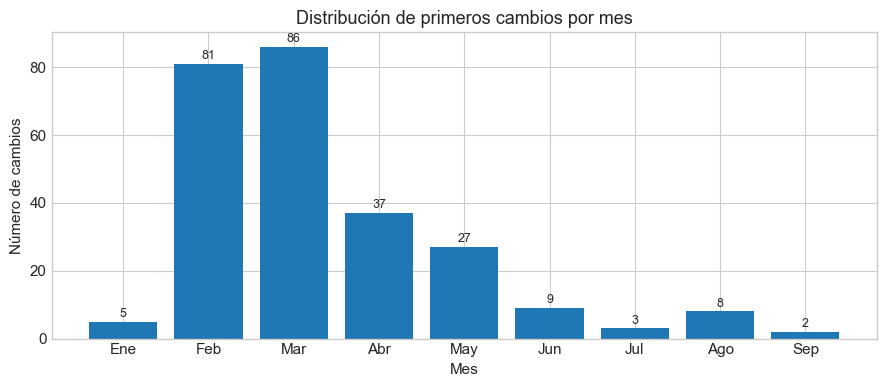

In [95]:
fig, ax = plt.subplots(figsize=(9,4))
conteo_mes = (df_mes.groupby('First_Change_Month')
                    .size()
                    .reindex(mes_order)
                    .fillna(0)
                    .astype(int))
ax.bar(conteo_mes.index.astype(str), conteo_mes.values, color="#1f77b4")
ax.set_title("Distribución de primeros cambios por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de cambios")
for x, v in enumerate(conteo_mes.values):
    ax.text(x, v+0.5, str(v), ha='center', va='bottom', fontsize=9)
savefig("01_cambios_por_mes.png")

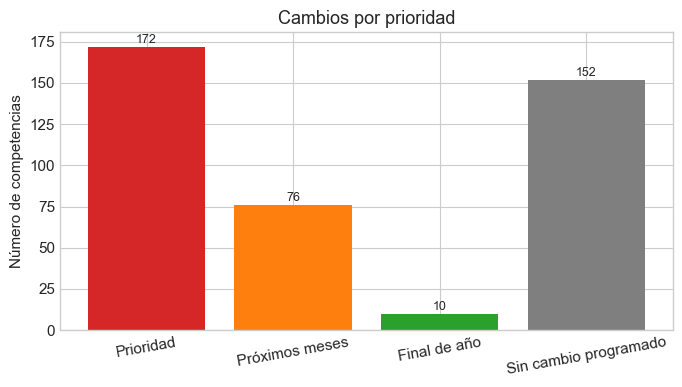

In [96]:
fig, ax = plt.subplots(figsize=(7,4))
conteo_prio = (df['Priority_Level']
               .value_counts()
               .reindex(["Prioridad","Próximos meses","Final de año","Sin cambio programado"])
               .fillna(0)
               .astype(int))
ax.bar(conteo_prio.index, conteo_prio.values, color=["#d62728","#ff7f0e","#2ca02c","#7f7f7f"])
ax.set_title("Cambios por prioridad")
ax.set_ylabel("Número de competencias")
for x, v in enumerate(conteo_prio.values):
    ax.text(x, v+0.5, str(v), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=10)
savefig("02_cambios_por_prioridad.png")

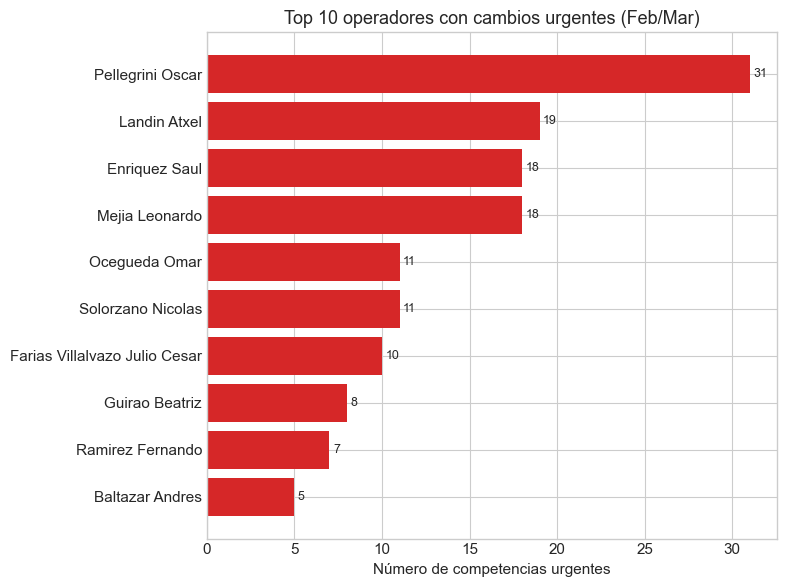

In [97]:
fig, ax = plt.subplots(figsize=(8,6))
top_emp_urg = (df_urgente.groupby('Employee').size()
               .sort_values(ascending=False).head(10))
ax.barh(top_emp_urg.index[::-1], top_emp_urg.values[::-1], color="#d62728")
ax.set_title("Top 10 operadores con cambios urgentes (Feb/Mar)")
ax.set_xlabel("Número de competencias urgentes")
for i, v in enumerate(top_emp_urg.values[::-1]):
    ax.text(v+0.2, i, str(v), va='center', fontsize=9)
savefig("03_top10_operadores_urgentes.png")

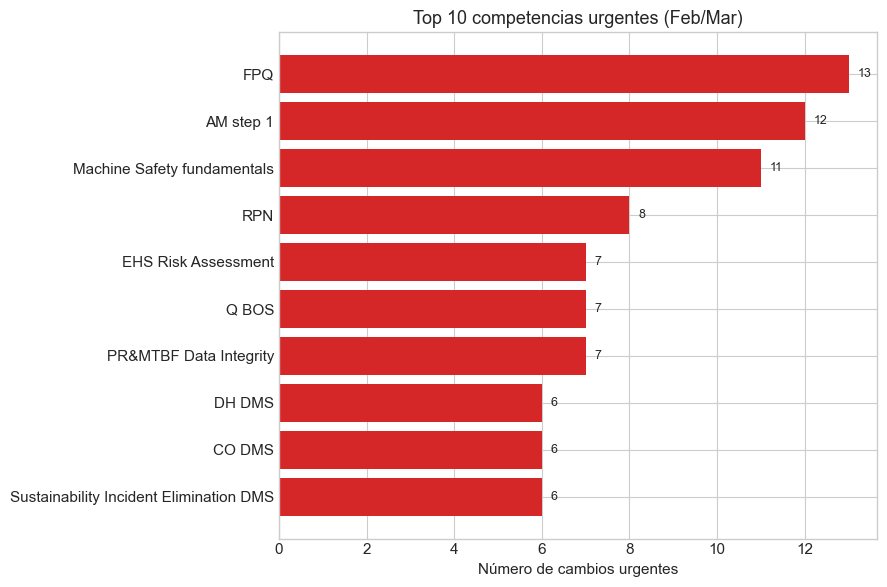

In [98]:
fig, ax = plt.subplots(figsize=(9,6))
top_comp_urg = (df_urgente.groupby('Competency').size()
                .sort_values(ascending=False).head(10))
ax.barh(top_comp_urg.index[::-1], top_comp_urg.values[::-1], color="#d62728")
ax.set_title("Top 10 competencias urgentes (Feb/Mar)")
ax.set_xlabel("Número de cambios urgentes")
for i, v in enumerate(top_comp_urg.values[::-1]):
    ax.text(v+0.2, i, str(v), va='center', fontsize=9)
savefig("04_top10_competencias_urgentes.png")


C:\Users\jtinoco2\AppData\Local\Temp\ipykernel_25308\3050472045.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matrix = (df_mes.groupby(['Employee','First_Change_Month'])


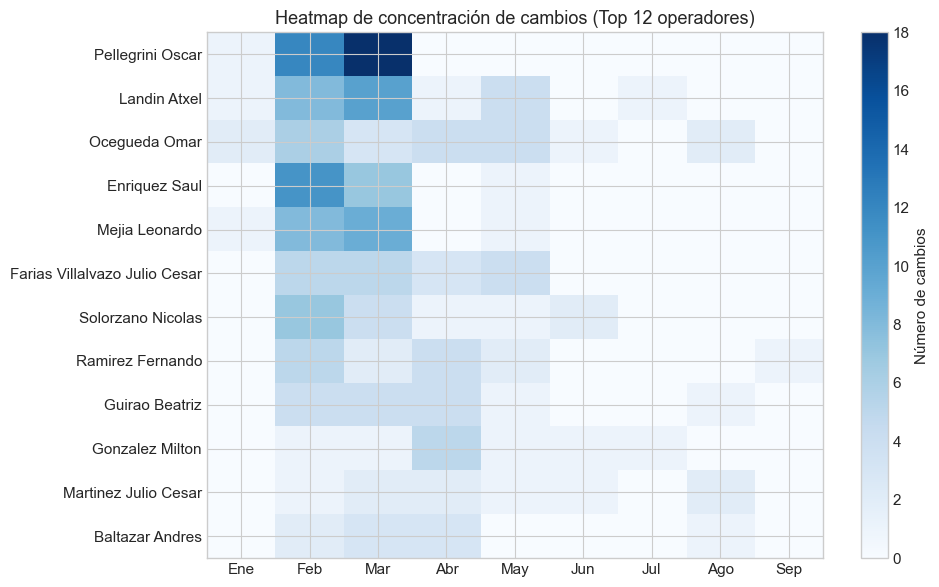

In [100]:
# Matriz empleado vs mes (para los que sí tienen mes de cambio)
matrix = (df_mes.groupby(['Employee','First_Change_Month'])
               .size().unstack(fill_value=0)
               .reindex(columns=mes_order))

top_empleados = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
mat = matrix.loc[top_empleados]

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(mat.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns)
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index)
ax.set_title("Heatmap de concentración de cambios (Top 12 operadores)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Número de cambios')
savefig("05_heatmap_operador_mes.png")


## Análisis con solo el archivo caps actualizado :

In [58]:
import pandas as pd
import numpy as np

df = pd.read_excel("QM-CAPS.xlsx", engine="openpyxl")
df.columns = df.columns.str.strip()
month_cols = ["Dec","Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep"]
month_cols = [m for m in month_cols if m in df.columns]
df_caps = df[["Employee", "Competency", "Current", "Target"] + month_cols].copy()

# Limpieza adicional
df_caps["Employee"] = df_caps["Employee"].str.strip()
df_caps["Competency"] = df_caps["Competency"].str.strip()

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1033 entries, 0 to 1032
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BU          1033 non-null   object 
 1   Cell        1033 non-null   object 
 2   IMDL        39 non-null     float64
 3   Employee    1033 non-null   object 
 4   Competency  1033 non-null   object 
 5   Current     1033 non-null   int64  
 6   Role        1033 non-null   object 
 7   Target      1033 non-null   int64  
 8   Feb         1033 non-null   int64  
 9   Mar         1033 non-null   int64  
 10  Abr         1033 non-null   int64  
 11  May         1033 non-null   int64  
 12  Jun         1033 non-null   int64  
 13  Jul         1033 non-null   int64  
 14  Ago         1033 non-null   int64  
 15  Sep         1033 non-null   int64  
dtypes: float64(1), int64(10), object(5)
memory usage: 129.3+ KB


In [60]:
def detectar_todos_los_cambios(row):
    cambios = []
    meses = month_cols
    
    for i in range(1, len(meses)):
        prev_val = row[meses[i-1]]
        curr_val = row[meses[i]]
        
        if curr_val > prev_val:
            cambios.append({
                "Employee": row["Employee"],
                "Competency": row["Competency"],
                "Current": row["Current"],
                "Target": row["Target"],
                "Month": meses[i],
                "Change_From": prev_val,
                "Change_To": curr_val
            })
    
    return cambios

# Expandir la lista de cambios a un dataframe
all_changes = []
for _, row in df_caps.iterrows():
    all_changes.extend(detectar_todos_los_cambios(row))

df_changes = pd.DataFrame(all_changes)
df_changes.head()

,Employee,Competency,Current,Target,Month,Change_From,Change_To
0,Aguilar Pedro,Coaching on the floor,1,2,Mar,1,2
1,Aguilar Pedro,QRP,2,3,Mar,2,3
2,Aguilar Pedro,Safety Map,2,3,Abr,2,3
3,Aguilar Pedro,Safety Trigger,2,3,May,2,3
4,Baltazar Andres,5S,2,3,Mar,2,3


In [61]:
df_changes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Employee     299 non-null    object
 1   Competency   299 non-null    object
 2   Current      299 non-null    int64 
 3   Target       299 non-null    int64 
 4   Month        299 non-null    object
 5   Change_From  299 non-null    int64 
 6   Change_To    299 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 16.5+ KB


In [62]:
def prioridad(mes):
    if mes in ["Mar"]:
        return "Prioridad"
    elif mes in ["Abr","May","Jun","Jul"]:
        return "Próximos meses"
    elif mes in ["Ago","Sep"]:
        return "Final de año"
    else:
        return "Histórico (Dec/Ene)"

df_changes["Priority_Level"] = df_changes["Month"].apply(prioridad)

In [63]:
df_changes = df_changes[df_changes["Current"] != df_changes["Target"]]
df_changes = df_changes[df_changes["Current"] <= df_changes["Target"]]

In [64]:
kpis = {
    "Total cambios detectados": len(df_changes),
    "Urgentes (Marzo)": (df_changes["Priority_Level"]=="Prioridad").sum(),
    "Próximos meses (Abr–Jul)": (df_changes["Priority_Level"]=="Próximos meses").sum(),
    "Final de año (Ago–Sep)": (df_changes["Priority_Level"]=="Final de año").sum(),
    "Empleados con múltiples cambios": df_changes["Employee"].value_counts().gt(1).sum() }
kpis

{'Total cambios detectados': 293,
 'Urgentes (Marzo)': np.int64(82),
 'Próximos meses (Abr–Jul)': np.int64(206),
 'Final de año (Ago–Sep)': np.int64(5),
 'Empleados con múltiples cambios': np.int64(26)}

In [65]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

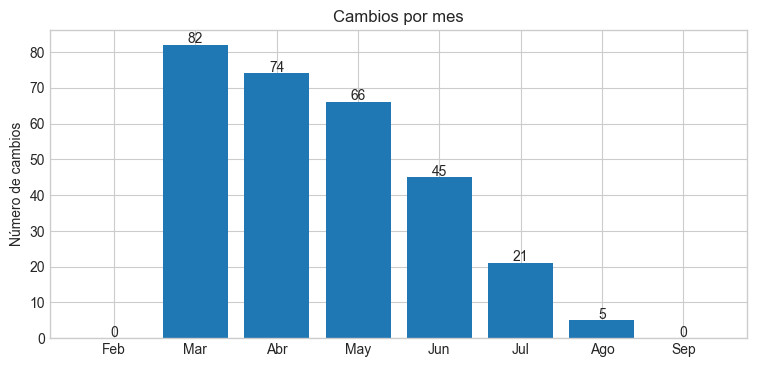

In [66]:
fig, ax = plt.subplots(figsize=(9,4))
counts = df_changes["Month"].value_counts().reindex(month_cols).fillna(0)
ax.bar(counts.index, counts.values, color="#1f77b4")
ax.set_title("Cambios por mes")
ax.set_ylabel("Número de cambios")

for i,v in enumerate(counts.values):
    ax.text(i, v+0.5, str(int(v)), ha="center")
plt.show()

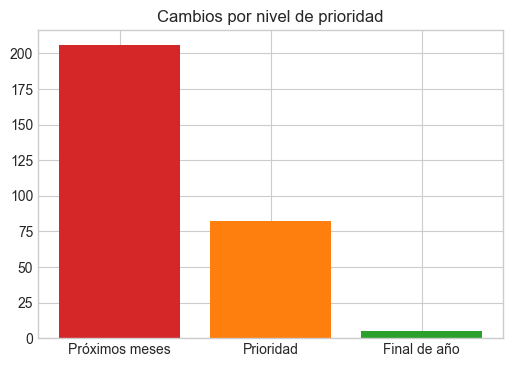

In [67]:
fig, ax = plt.subplots(figsize=(6,4))

prio_counts = df_changes["Priority_Level"].value_counts()
ax.bar(prio_counts.index, prio_counts.values, color=["#d62728","#ff7f0e","#2ca02c","#7f7f7f"])
ax.set_title("Cambios por nivel de prioridad")
plt.show()

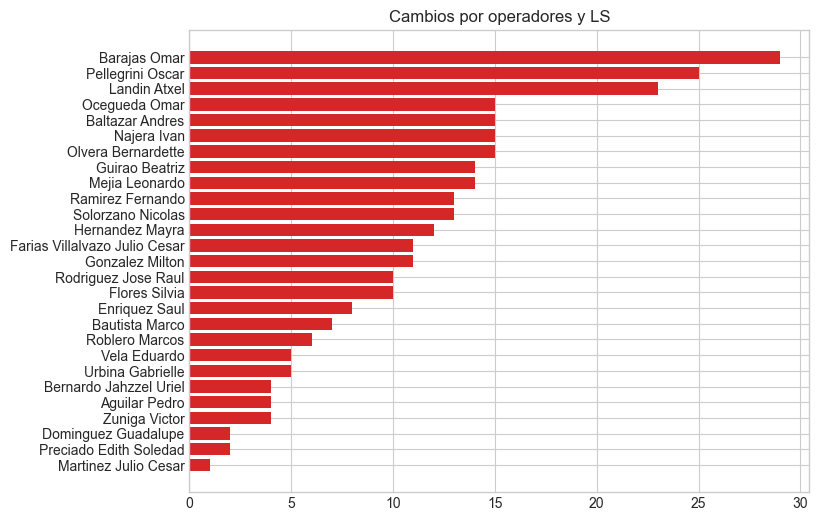

In [68]:
fig, ax = plt.subplots(figsize=(8,6))
top_emp = df_changes["Employee"].value_counts()
ax.barh(top_emp.index[::-1], top_emp.values[::-1], color="#d62728")
ax.set_title("Cambios por operadores y LS")
plt.show()

In [69]:
top_emp

Employee
Barajas Omar                     29
Pellegrini Oscar                 25
Landin Atxel                     23
Ocegueda Omar                    15
Baltazar Andres                  15
Najera Ivan                      15
Olvera Bernardette               15
Guirao Beatriz                   14
Mejia Leonardo                   14
Ramirez Fernando                 13
Solorzano Nicolas                13
Hernandez Mayra                  12
Farias Villalvazo Julio Cesar    11
Gonzalez Milton                  11
Rodriguez Jose Raul              10
Flores Silvia                    10
Enriquez Saul                     8
Bautista Marco                    7
Roblero Marcos                    6
Vela Eduardo                      5
Urbina Gabrielle                  5
Bernardo Jahzzel Uriel            4
Aguilar Pedro                     4
Zuniga Victor                     4
Dominguez Guadalupe               2
Preciado Edith Soledad            2
Martinez Julio Cesar              1
Name: count, dtype:

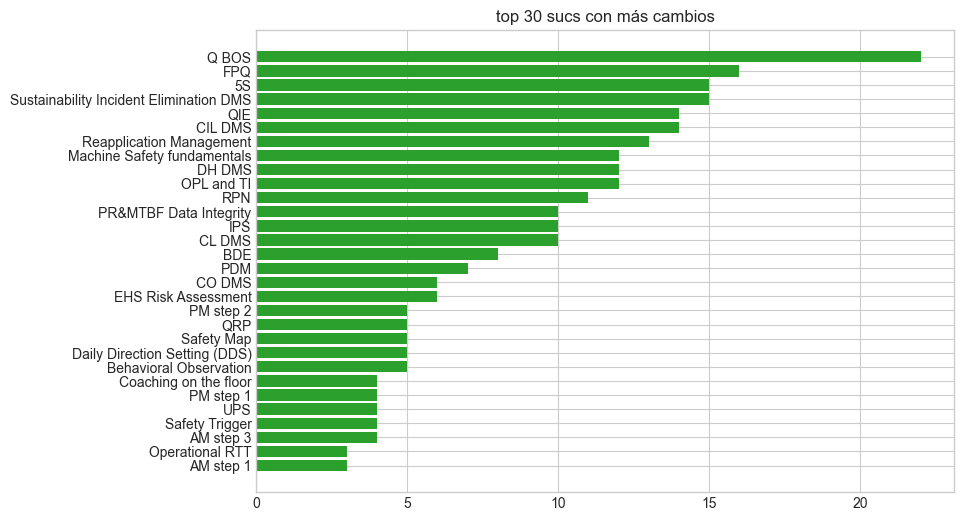

In [70]:
fig, ax = plt.subplots(figsize=(9,6))
top_comp = df_changes["Competency"].value_counts().head(30)
ax.barh(top_comp.index[::-1], top_comp.values[::-1], color="#2ca02c")
ax.set_title("top 30 sucs con más cambios")
plt.show()

In [71]:
top_comp

Competency
Q BOS                                      22
FPQ                                        16
5S                                         15
Sustainability Incident Elimination DMS    15
QIE                                        14
CIL DMS                                    14
Reapplication Management                   13
Machine Safety fundamentals                12
DH DMS                                     12
OPL and TI                                 12
RPN                                        11
PR&MTBF Data Integrity                     10
IPS                                        10
CL DMS                                     10
BDE                                         8
PDM                                         7
CO DMS                                      6
EHS Risk Assessment                         6
PM step 2                                   5
QRP                                         5
Safety Map                                  5
Daily Direction Setting

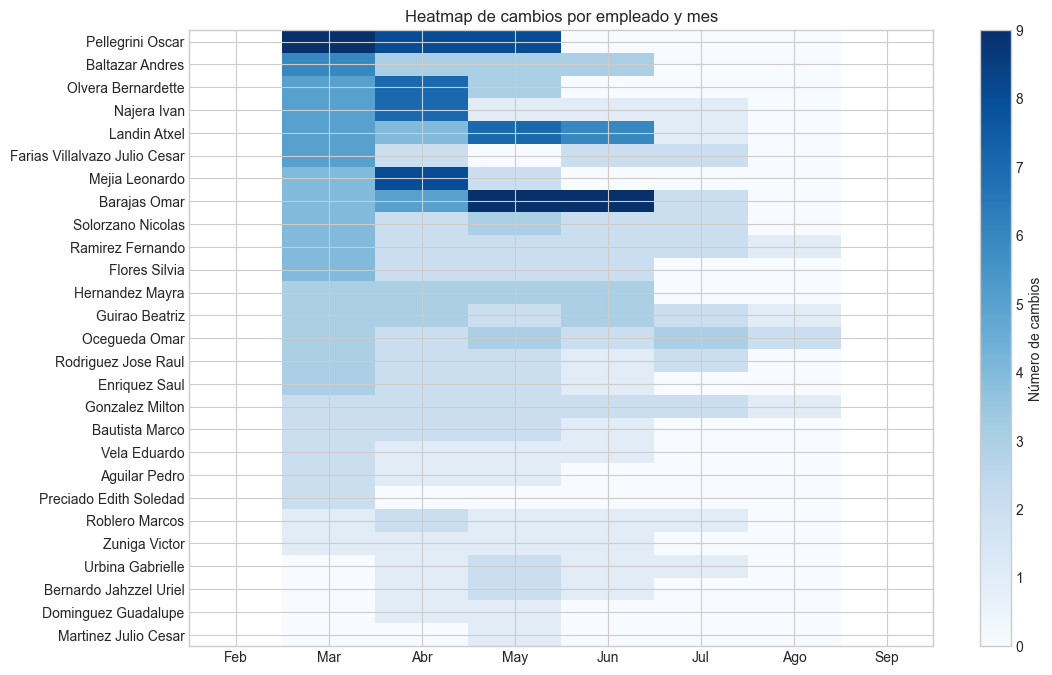

In [72]:
pivot = df_changes.pivot_table(index="Employee", columns="Month", values="Change_To", aggfunc="count", fill_value=0)
pivot = pivot.reindex(columns=month_cols).sort_values(by=month_cols, ascending=False)

plt.figure(figsize=(12,8))
plt.imshow(pivot, cmap="Blues", aspect="auto")
plt.xticks(range(len(month_cols)), month_cols)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Número de cambios")
plt.title("Heatmap de cambios por empleado y mes")
plt.show()

In [73]:
# 1) Crear columna con el tipo de cambio detectado
df_changes["Change_Type"] = df_changes["Change_From"].astype(str) + " → " + df_changes["Change_To"].astype(str)

# 2) Tabla resumen: cuántas veces aparece cada tipo de cambio
change_summary = df_changes["Change_Type"].value_counts().reset_index()
change_summary.columns = ["Tipo de cambio", "Cantidad"]

print("=== Resumen de tipos de cambio detectados ===")
change_summary

=== Resumen de tipos de cambio detectados ===


,Tipo de cambio,Cantidad
0,2 → 3,154
1,1 → 2,113
2,1 → 3,19
3,3 → 4,4
4,2 → 4,3


In [74]:
# 3) Tabla más detallada por competencia
change_by_comp = (
    df_changes.groupby(["Change_Type", "Competency"])
    .size()
    .reset_index(name="Conteo")
    .sort_values(["Change_Type", "Conteo"], ascending=[True, False])
)

print("\n=== Competencias involucradas por tipo de cambio ===")
change_by_comp


=== Competencias involucradas por tipo de cambio ===


,Change_Type,Competency,Conteo
19,1 → 2,Machine Safety fundamentals,11
27,1 → 2,PR&MTBF Data Integrity,9
32,1 → 2,RPN,9
29,1 → 2,Q BOS,7
11,1 → 2,EHS Risk Assessment,6
...,...,...,...
86,2 → 4,Safety Trigger,1
87,3 → 4,5S,1
88,3 → 4,Behavioral Observation,1
89,3 → 4,CL DMS,1


In [89]:
df_changes.head()

,Employee,Competency,Current,Target,Month,Change_From,Change_To,Priority_Level,Change_Type
0,Aguilar Pedro,Coaching on the floor,1,2,Mar,1,2,Prioridad,1 → 2
1,Aguilar Pedro,QRP,2,3,Mar,2,3,Prioridad,2 → 3
2,Aguilar Pedro,Safety Map,2,3,Abr,2,3,Próximos meses,2 → 3
3,Aguilar Pedro,Safety Trigger,2,3,May,2,3,Próximos meses,2 → 3
4,Baltazar Andres,5S,2,3,Mar,2,3,Prioridad,2 → 3


In [90]:
# 4) Tabla por empleado y tipo de cambio
change_by_employee = (
    df_changes.groupby(["Change_Type", "Employee", "Month", 'Competency'])
    .size()
    .reset_index(name="Conteo")
    .sort_values(["Change_Type", "Conteo"], ascending=[True, False])
)

print("\n=== Empleados involucrados por tipo de cambio ===")
change_by_employee.head()


=== Empleados involucrados por tipo de cambio ===


,Change_Type,Employee,Month,Competency,Conteo
24,1 → 2,Barajas Omar,May,Q BOS,2
32,1 → 2,Farias Villalvazo Julio Cesar,Mar,Machine Safety fundamentals,2
0,1 → 2,Aguilar Pedro,Mar,Coaching on the floor,1
1,1 → 2,Baltazar Andres,Mar,Coaching on the floor,1
2,1 → 2,Baltazar Andres,Mar,ET Training Basic,1


In [91]:
change_by_employee.to_excel("tabla.xlsx")

## Tercer análisis :

In [2]:
# ======================================
# 1. IMPORTAR LIBRERÍAS Y ARCHIVOS
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

qm = pd.read_excel("QM-CAPS.xlsx", sheet_name="Sheet2", engine="openpyxl")
data = pd.read_excel("data_new.xlsx", sheet_name="Export", engine="openpyxl")

# Normalizar nombres para evitar problemas
qm.columns = qm.columns.str.strip()
data.columns = data.columns.str.strip()

In [4]:
qm

,BU,Cell,IMDL,Employee,Competency,Current,Role,Target,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep
0,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,5S,3,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3
1,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM Overview,2,Line Coordinator - Phase 1,2,2,2,2,2,2,2,2,2
2,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 1,3,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3
3,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 2,2,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2
4,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 3,2,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028,FILTERS,FM_Caps,NaN,Najera Ivan,Qualification Process and Skills Management Sy...,1,Equipment Owner Secondary - Phase 1,3,1,1,1,1,1,1,1,1
1029,FILTERS,FM_Caps,NaN,Najera Ivan,Reapplication Management,1,Equipment Owner Secondary - Phase 1,3,1,1,1,1,1,1,1,1
1030,FILTERS,FM_Caps,NaN,Najera Ivan,RPN,1,Equipment Owner Secondary - Phase 1,2,1,1,2,2,2,2,2,2
1031,FILTERS,FM_Caps,NaN,Najera Ivan,Sustainability Incident Elimination DMS,1,Equipment Owner Secondary - Phase 1,3,1,1,1,1,1,1,1,1


In [3]:
data

,Role,Employee,Role.1,Competency,OnTarget,Current,Target
0,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,5S,1,3,3
1,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM Overview,1,2,2
2,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 1,1,3,3
3,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 2,0,2,3
4,Line Coordinator,Aguilar Pedro,Line Coordinator - Phase 1,AM step 3,0,2,3
...,...,...,...,...,...,...,...
1006,PT,Ocegueda Omar,MT/ MT Specialists - Phase 1,UPS,1,2,2
1007,PT,Ocegueda Omar,PM Champion - Phase 2,BDE,1,3,3
1008,PT,Ocegueda Omar,PM Champion - Phase 2,DH DMS,0,2,4
1009,PT,Ocegueda Omar,PM Champion - Phase 2,MPS,0,2,3


In [ ]:
# ======================================
# 2. EMPAREJAR DATASETS POR Employee + Competency
# ======================================
merge_cols = ["Employee", "Competency"]

merged = qm.merge(
    data[["Employee","Competency","Current"]].rename(columns={"Current":"Current_new"}),
    on=["Employee","Competency"],
    how="left")

# ======================================
# 3. DETECTAR CAMBIOS EN CURRENT
# ======================================
merged["Cambio"] = np.where(
    merged["Current"] != merged["Current_new"],
    True,
    False
)

In [6]:
merged

,BU,Cell,IMDL,Employee,Competency,Current,Role,Target,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Current_new,Cambio
0,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,5S,3,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3,3.0,False
1,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM Overview,2,Line Coordinator - Phase 1,2,2,2,2,2,2,2,2,2,2.0,False
2,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 1,3,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3,3.0,False
3,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 2,2,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2,2.0,False
4,FILTERS,FM_Caps,1.000133e+09,Aguilar Pedro,AM step 3,2,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2,2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275,FILTERS,FM_Caps,NaN,Najera Ivan,Qualification Process and Skills Management Sy...,1,Equipment Owner Secondary - Phase 1,3,1,1,1,1,1,1,1,1,NaN,True
1276,FILTERS,FM_Caps,NaN,Najera Ivan,Reapplication Management,1,Equipment Owner Secondary - Phase 1,3,1,1,1,1,1,1,1,1,NaN,True
1277,FILTERS,FM_Caps,NaN,Najera Ivan,RPN,1,Equipment Owner Secondary - Phase 1,2,1,1,2,2,2,2,2,2,NaN,True
1278,FILTERS,FM_Caps,NaN,Najera Ivan,Sustainability Incident Elimination DMS,1,Equipment Owner Secondary - Phase 1,3,1,1,1,1,1,1,1,1,NaN,True


In [7]:
# ======================================
# 4. ACTUALIZAR CURRENT EN QM-CAPS
# ======================================
merged["Current_actualizado"] = merged["Current_new"].fillna(merged["Current"])

# ======================================
# 5. IDENTIFICAR PRÓXIMO CAMBIO (target > current)
# ======================================
meses = ["Feb","Mar","Abr","May","Jun","Jul","Ago","Sep"]

def proximo_cambio(row):
    current = row["Current_actualizado"]
    for mes in meses:
        valor = row.get(mes)
        if pd.notna(valor) and valor > current:
            return mes, valor
    return None, None

merged[["Mes_prox_cambio","Nivel_prox_cambio"]] = merged.apply(
    lambda r: pd.Series(proximo_cambio(r)),
    axis=1
)

In [8]:
# ======================================
# 6. TABLA FINAL REQUERIDA
# ======================================
tabla = merged[[
    "Employee","Competency","Current_actualizado",
    "Mes_prox_cambio","Nivel_prox_cambio","Target"
]]

In [9]:
tabla

,Employee,Competency,Current_actualizado,Mes_prox_cambio,Nivel_prox_cambio,Target
0,Aguilar Pedro,5S,3.0,None,NaN,3
1,Aguilar Pedro,AM Overview,2.0,None,NaN,2
2,Aguilar Pedro,AM step 1,3.0,None,NaN,3
3,Aguilar Pedro,AM step 2,2.0,None,NaN,3
4,Aguilar Pedro,AM step 3,2.0,None,NaN,3
...,...,...,...,...,...,...
1275,Najera Ivan,Qualification Process and Skills Management Sy...,1.0,None,NaN,3
1276,Najera Ivan,Reapplication Management,1.0,None,NaN,3
1277,Najera Ivan,RPN,1.0,Abr,2.0,2
1278,Najera Ivan,Sustainability Incident Elimination DMS,1.0,None,NaN,3


In [ ]:
# ======================================
# 7. ANÁLISIS DE ATRASOS
# ======================================
# Regla: si YA deberíamos haber avanzado según el mes actual
mes_actual = "Mar"   # <- Cámbialo dinámicamente si quieres

merged["Atrasado"] = np.where(
    (merged["Mes_prox_cambio"].notna()) &
    (meses.index(merged["Mes_prox_cambio"]) < meses.index(mes_actual)),
    True, 
    False
)

In [ ]:
# ======================================
# 8. GRÁFICAS REQUERIDAS
# ======================================

# --- Pronósticos por mes ---
pronosticos_mes = merged["Mes_prox_cambio"].value_counts().sort_index()

plt.figure(figsize=(8,5))
pronosticos_mes.plot(kind="bar")
plt.title("Pronósticos de Cambios por Mes")
plt.xlabel("Mes")
plt.ylabel("Número de cambios pronosticados")
plt.show()

# --- Pronósticos por competencia ---
pronosticos_comp = merged[merged["Mes_prox_cambio"].notna()]["Competency"].value_counts()

plt.figure(figsize=(8,5))
pronosticos_comp.plot(kind="bar")
plt.title("Pronósticos por Competencia")
plt.xlabel("Competencia")
plt.ylabel("Cantidad")
plt.show()

# --- Pendientes por empleado ---
pendientes = merged["Employee"].value_counts()
plt.figure(figsize=(8,5))
pendientes.plot(kind="bar")
plt.title("Pendientes por Empleado")
plt.xlabel("Empleado")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
# ======================================
# 9. GUARDAR TABLA FINAL
# ======================================
tabla.to_excel("Analisis_Cambios_CAPS.xlsx", index=False)